In [1]:
import os
import shutil
import pandas as pd

# Label mapping
label_map = {
    0: 'No_DR',
    1: 'Mild_DR',
    2: 'Moderate_DR',
    3: 'Severe_DR',
    4: 'Proliferative_DR'
}

# Base path
base_dir = "Dataset"
data_new_dir = os.path.join(base_dir, "data_modfi")  # New base for organized data
os.makedirs(data_new_dir, exist_ok=True)

# Config for each dataset split
splits = {
    'train': {
        'csv': 'train_1.csv',
        'img_dir': os.path.join(base_dir, 'train_images', 'train_images'),
        'out_dir': os.path.join(data_new_dir, 'train_new')
    },
    'val': {
        'csv': 'valid.csv',
        'img_dir': os.path.join(base_dir, 'val_images', 'val_images'),
        'out_dir': os.path.join(data_new_dir, 'val_new')
    },
    'test': {
        'csv': 'test.csv',
        'img_dir': os.path.join(base_dir, 'test_images', 'test_images'),
        'out_dir': os.path.join(data_new_dir, 'test_new')
    }
}

# Process each split
for split_name, config in splits.items():
    print(f"\n🔄 Processing {split_name.upper()}...")

    # Load CSV
    csv_path = os.path.join(base_dir, config['csv'])
    df = pd.read_csv(csv_path)

    # Create output folder and class subfolders
    for class_name in label_map.values():
        os.makedirs(os.path.join(config['out_dir'], class_name), exist_ok=True)

    # Copy images
    for idx, row in df.iterrows():
        img_file = row['id_code'] + '.png'  # Change to .jpg if needed
        class_folder = label_map[row['diagnosis']]

        src = os.path.join(config['img_dir'], img_file)
        dst = os.path.join(config['out_dir'], class_folder, img_file)

        if os.path.exists(src):
            shutil.copy2(src, dst)
        else:
            print(f"⚠️ Image not found: {src}")

    print(f"✅ {split_name.upper()} completed. Images processed: {len(df)}")

print("\n🎉 All datasets saved inside 'data_new/' folder successfully.")



🔄 Processing TRAIN...
✅ TRAIN completed. Images processed: 2930

🔄 Processing VAL...
✅ VAL completed. Images processed: 366

🔄 Processing TEST...
✅ TEST completed. Images processed: 366

🎉 All datasets saved inside 'data_new/' folder successfully.


In [9]:
# MobileNEt+SVM

In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical

# Path to your dataset folder
dataset_folder = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new"

# Define ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Function to load images and apply augmentation, then save to the existing folder
def load_and_augment_images(class_folder, target_count):
    class_path = os.path.join(dataset_folder, class_folder)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('jpg', 'jpeg', 'png'))]  # Image extensions
    
    # Count current number of images in the class folder
    current_count = len(image_files)
    
    # Augment only if the class has fewer images than the target_count
    if current_count < target_count:
        # Loop through images and apply augmentation
        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            
            # Load image
            img = load_img(img_path, target_size=(150, 150))  # Resize if necessary
            img = img_to_array(img)
            img = np.expand_dims(img, axis=0)
            
            # Augment and save the images
            img_gen = datagen.flow(img, batch_size=1, save_to_dir=class_path, save_prefix=class_folder, save_format='jpeg')
            # Apply augmentation until the number of images reaches target_count
            augment_count = target_count - current_count
            for _ in range(augment_count):  # Augment the remaining required number of images
                img_gen.next()
            current_count += augment_count  # Update the count after augmentation

# Calculate target class (the class with the highest number of images)
class_counts = {
    "Mild_DR": 370,
    "Moderate_DR": 422,
    "No_DR": 454,
    "Proliferative_DR": 295,
    "Severe_DR": 193
}

# Find the class with the highest number of images
target_class = max(class_counts, key=class_counts.get)
target_count = class_counts[target_class]

# Apply augmentation for all classes except the target
for class_folder in class_counts:
    if class_folder != target_class:
        load_and_augment_images(class_folder, target_count)

print(f"Augmentation completed. All classes have been augmented to match the target class '{target_class}' with {target_count} images.")



Augmentation completed. All classes have been augmented to match the target class 'No_DR' with 454 images.


In [5]:
import os
import numpy as np
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

# Path to your dataset folder
dataset_folder = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new"

# Initialize ImageDataGenerator for rescaling and validation split
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values to between 0 and 1
    validation_split=0.3 # Use 20% of the data for validation
)

# Prepare training data
train_generator = datagen.flow_from_directory(
    dataset_folder,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'  # Use the training subset (80% of the data)
)

# Prepare validation data
validation_generator = datagen.flow_from_directory(
    dataset_folder,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # Use the validation subset (20% of the data)
)

# Load MobileNet pre-trained model without the top layer (used for feature extraction)
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model layers (we don't want to train these)
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers for classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)  # Fully connected layer
predictions = Dense(5, activation='softmax')(x)  # 5 classes, change as per your dataset

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Define a checkpoint to save the best model during training
checkpoint = ModelCheckpoint('mobilenet_trained.h5', save_best_only=True, save_weights_only=False)

# Train the model
model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

# Save the final model
model.save('mobilenet_trained_final.h5')


Found 1590 images belonging to 5 classes.
Found 679 images belonging to 5 classes.


Epoch 1/10
50/50 [==============================] - 164s 3s/step - loss: 1.2257 - accuracy: 0.6340 - val_loss: 1.3735 - val_accuracy: 0.5066
Epoch 2/10
50/50 [==============================] - 162s 3s/step - loss: 0.5742 - accuracy: 0.7811 - val_loss: 1.1790 - val_accuracy: 0.5670
Epoch 3/10
50/50 [==============================] - 194s 4s/step - loss: 0.4621 - accuracy: 0.8208 - val_loss: 1.1743 - val_accuracy: 0.5832
Epoch 4/10
50/50 [==============================] - 204s 4s/step - loss: 0.3870 - accuracy: 0.8516 - val_loss: 1.1278 - val_accuracy: 0.5920
Epoch 5/10
50/50 [==============================] - 204s 4s/step - loss: 0.3157 - accuracy: 0.8818 - val_loss: 1.1881 - val_accuracy: 0.5729
Epoch 6/10
50/50 [==============================] - 205s 4s/step - loss: 0.2812 - accuracy: 0.8950 - val_loss: 1.5186 - val_accuracy: 0.5434
Epoch 7/10
50/50 [==============================] - 201s 4s/step - loss: 0.2371 - accuracy: 0.9132 - val_loss: 1.1930 - val_accuracy: 0.5832
Epoch 8/10
50

In [6]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the trained MobileNet model
model = load_model('mobilenet_trained_final.h5')

# Define the target classes manually as a list
target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']

# Function to extract features using MobileNet (without the top layer)
def extract_features(class_folder):
    features = []
    labels = []
    
    class_path = os.path.join(dataset_folder, class_folder)
    
    # Get all image files in the class folder
    image_files = [f for f in os.listdir(class_path) if f.endswith(('jpg', 'jpeg', 'png'))]
    
    # Loop through images and extract features
    for img_name in image_files:
        img_path = os.path.join(class_path, img_name)
        
        # Load image
        img = load_img(img_path, target_size=(150, 150))  # Resize if necessary
        img = img_to_array(img)
        img = np.expand_dims(img, axis=0)
        
        # Preprocess the image for MobileNet
        img = img / 255.0  # Normalize the image
        
        # Extract features from the image using MobileNet
        feature = model.predict(img)
        features.append(feature.flatten())  # Flatten the feature vector to 1D
        
        # Assign the label (class) to the image
        labels.append(class_folder)
    
    return np.array(features), np.array(labels)

# Extract features for all classes
all_features = []
all_labels = []

for class_folder in os.listdir(dataset_folder):
    class_path = os.path.join(dataset_folder, class_folder)
    if os.path.isdir(class_path):
        features, labels = extract_features(class_folder)
        all_features.append(features)
        all_labels.append(labels)

# Combine features and labels
all_features = np.vstack(all_features)
all_labels = np.concatenate(all_labels)

# Map the class names to numerical labels based on the target_classes list
label_map = {class_name: idx for idx, class_name in enumerate(target_classes)}

# Convert labels to numerical values based on the manual mapping
encoded_labels = np.array([label_map[label] for label in all_labels])


1/1 [==============================] - 0s 32ms/step


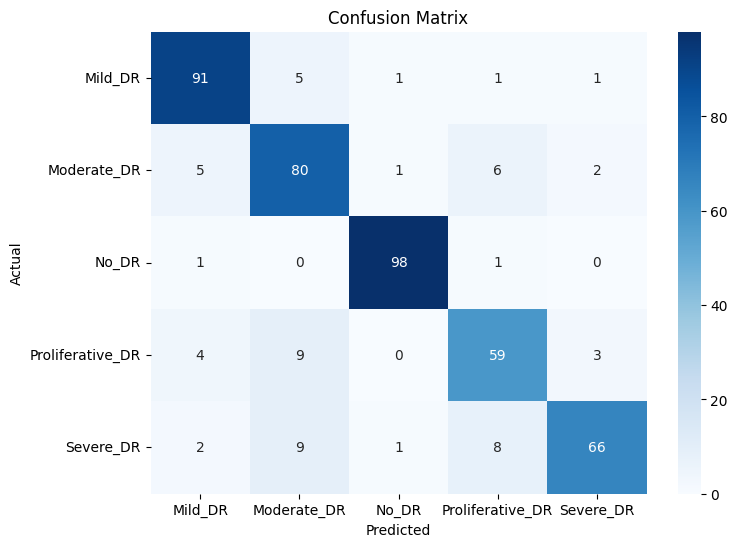

Classification Report:

                  precision    recall  f1-score   support

         Mild_DR       0.88      0.92      0.90        99
     Moderate_DR       0.78      0.85      0.81        94
           No_DR       0.97      0.98      0.98       100
Proliferative_DR       0.79      0.79      0.79        75
       Severe_DR       0.92      0.77      0.84        86

        accuracy                           0.87       454
       macro avg       0.87      0.86      0.86       454
    weighted avg       0.87      0.87      0.87       454



In [7]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(all_features, encoded_labels, test_size=0.2, random_state=42)

# Initialize and train the SVM classifier
svm_model = SVC(kernel='linear')  # You can experiment with different kernels like 'rbf'
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model using confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=target_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_classes, yticklabels=target_classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Display classification report
print("Classification Report:\n")
print(class_report)


In [8]:
import joblib

# Save the trained SVM model to a file
joblib.dump(svm_model, 'svm_mobile_trained.pkl')


['svm_mobile_trained.pkl']

In [8]:
#predction

1/1 [==============================] - 0s 262ms/step


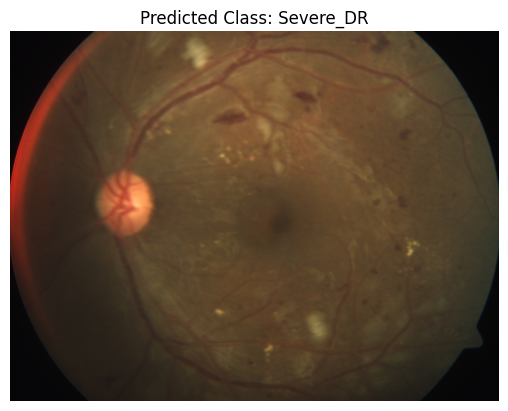

Predicted Class: Severe_DR


In [7]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import joblib
import matplotlib.pyplot as plt

# Load the trained MobileNet model
model = load_model('mobilenet_trained_final.h5')

# Load the trained SVM model
svm_model = joblib.load('svm_mobile_trained.pkl')

# Define the target classes manually as a list
target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']

# Function to preprocess the image and extract features using MobileNet
def extract_features(image_path):
    # Load the image
    img = load_img(image_path, target_size=(150, 150))  # Resize to match the input size of MobileNet
    img = img_to_array(img)  # Convert image to numpy array
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    
    # Preprocess the image for MobileNet (normalize)
    img = img / 255.0  # Normalize pixel values to between 0 and 1
    
    # Extract features from the image using MobileNet
    features = model.predict(img)  # Get the features from the MobileNet model
    return features.flatten()  # Flatten the feature vector to 1D

# Function to predict the class of a single image
def predict_image(image_path):
    # Extract features from the image
    features = extract_features(image_path)
    
    # Use the SVM model to predict the class
    predicted_class = svm_model.predict([features])  # Predict class using the trained SVM model
    
    # Get the predicted class label
    predicted_class_label = target_classes[predicted_class[0]]
    
    # Display the image with the predicted class
    img = load_img(image_path)
    plt.imshow(img)
    plt.title(f"Predicted Class: {predicted_class_label}")
    plt.axis('off')  # Hide axes
    plt.show()
    
    return predicted_class_label

# Example usage: predict a single image
image_path = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new\Severe_DR\2f42e20db938.png"  # Replace with the path to the image you want to predict
predicted_class = predict_image(image_path)

print(f"Predicted Class: {predicted_class}")


In [ ]:
#vit model

c:\Users\1033\.conda\envs\envs\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\1033\.conda\envs\envs\lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/7, Loss: 1.0970372013878404, Accuracy: 63.58126721763085%
Validation Accuracy: 72.90748898678414%
Epoch 2/7, Loss: 0.6614218077115845, Accuracy: 76.08815426997245%
Validation Accuracy: 73.568281938326%
Epoch 3/7, Loss: 0.5310502282360143, Accuracy: 80.55096418732782%
Validation Accuracy: 75.77092511013215%
Epoch 4/7, Loss: 0.37821683287620544, Accuracy: 87.65840220385675%
Validation Accuracy: 77.97356828193833%
Epoch 5/7, Loss: 0.28951370814128924, Accuracy: 90.68870523415978%
Validation Accuracy: 77.31277533039648%
Epoch 6/7, Loss: 0.22673913012993963, Accuracy: 93.49862258953168%
Validation Accuracy: 75.99118942731278%
Epoch 7/7, Loss: 0.1898489403293321, Accuracy: 94.49035812672176%
Validation Accuracy: 78.19383259911895%


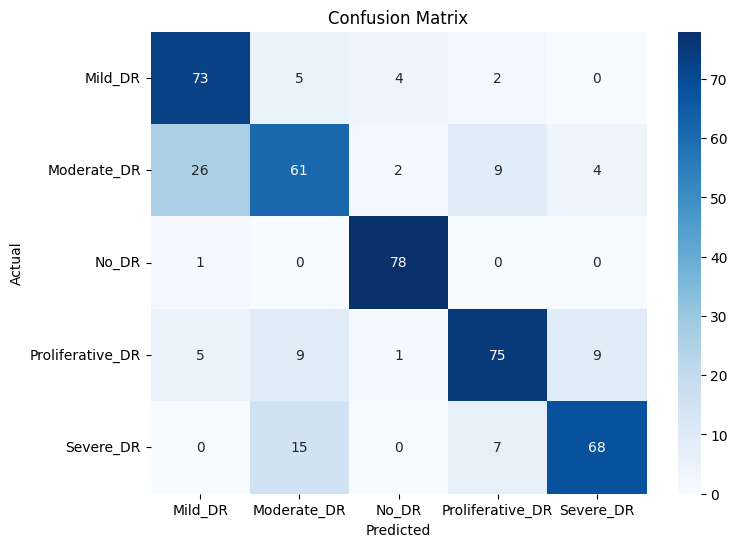

Classification Report:

                  precision    recall  f1-score   support

         Mild_DR       0.70      0.87      0.77        84
     Moderate_DR       0.68      0.60      0.64       102
           No_DR       0.92      0.99      0.95        79
Proliferative_DR       0.81      0.76      0.78        99
       Severe_DR       0.84      0.76      0.80        90

        accuracy                           0.78       454
       macro avg       0.79      0.79      0.79       454
    weighted avg       0.78      0.78      0.78       454



In [1]:

# Path to your dataset folder
dataset_folder = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\train_new"

import os
import numpy as np
import torch
from torch import nn, optim
from transformers import ViTForImageClassification, ViTFeatureExtractor
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms



# Define target classes manually as per your previous setup
target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']

# Initialize ViT model and feature extractor from Hugging Face
feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224-in21k')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k', num_labels=len(target_classes))

# Replace the classifier head with a custom one (as we have 5 classes)
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, len(target_classes))  # 5 output classes
)

# Define image transformation (to resize and normalize the images)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as per ViT's original settings
])

# Custom Dataset class to load images from the folder
class RetinalDataset(Dataset):
    def __init__(self, dataset_folder, target_classes, transform=None):
        self.dataset_folder = dataset_folder
        self.target_classes = target_classes
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Collecting images and labels
        for label, class_name in enumerate(target_classes):
            class_path = os.path.join(dataset_folder, class_name)
            for img_name in os.listdir(class_path):
                if img_name.endswith(('jpg', 'jpeg', 'png')):
                    self.images.append(os.path.join(class_path, img_name))
                    self.labels.append(label)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")  # Convert to RGB if not
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# Initialize dataset and dataloaders
dataset = RetinalDataset(dataset_folder, target_classes, transform)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Save the best model based on validation accuracy
best_val_accuracy = 0.0
best_model_wts = model.state_dict()

# Training loop
epochs = 7
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(imgs).logits
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}, Accuracy: {train_accuracy}%")
    
    # Validation phase
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            
            outputs = model(imgs).logits
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_accuracy = 100 * correct / total
    print(f"Validation Accuracy: {val_accuracy}%")
    
    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_vit = model.state_dict()

# Load the best model weights
model.load_state_dict(best_model_vit)

# Evaluate the model
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        outputs = model(imgs).logits
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
class_report = classification_report(all_labels, all_preds, target_names=target_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_classes, yticklabels=target_classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Display classification report
print("Classification Report:\n")
print(class_report)


In [2]:
# Save the best model based on validation accuracy
torch.save(model.state_dict(), 'best_vit_model.pth')
print("Best model saved as 'best_vit_model.pth'")


Best model saved as 'best_vit_model.pth'


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


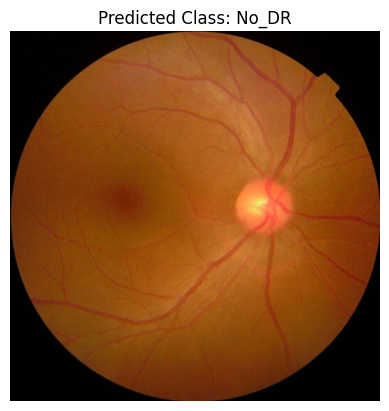

Predicted Class: No_DR


In [3]:
import torch
from transformers import ViTForImageClassification
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Define target classes manually as per your previous setup
target_classes = ['Mild_DR', 'Moderate_DR', 'No_DR', 'Proliferative_DR', 'Severe_DR']

# Load the saved model
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k', num_labels=len(target_classes))
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, len(target_classes))  # 5 output classes
)

# Load the model weights
model.load_state_dict(torch.load('best_vit_model.pth'))
model.eval()  # Set the model to evaluation mode

# Define image transformation (same as during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize as per ViT's original settings
])

# Function to predict the class of a single image
def predict_image(image_path):
    # Open the image
    image = Image.open(image_path).convert("RGB")

    # Preprocess the image
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

    # Make prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        logits = outputs.logits
        _, predicted_class = torch.max(logits, 1)
    
    # Get predicted class
    predicted_class_label = target_classes[predicted_class.item()]

    # Display the image with the predicted label
    plt.imshow(image)
    plt.title(f"Predicted Class: {predicted_class_label}")
    plt.axis('off')  # Hide axes
    plt.show()

    return predicted_class_label

# Example usage: predict a single image
image_path = r"Z:\Shaik_shariff\ARJUN\MAY\EffNet-SVM_A_Hybrid_Model_for_Diabetic_Retinopathy_Classification_Using_Retinal_Fundus_Images\DATASET\data_modfi\test_new\No_DR\e7b5dd5bab1f.png"  # Replace with the path to the image you want to predict
predicted_class = predict_image(image_path)

print(f"Predicted Class: {predicted_class}")
